In [1]:
# Setup & Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
    decode_predictions,
)

print("TensorFlow-Version:", tf.__version__)
print("GPU verfügbar:", tf.config.list_physical_devices("GPU"))


TensorFlow-Version: 2.20.0
GPU verfügbar: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Bild laden & vorbereiten
IMG_URL = "https://th.bing.com/th/id/R.3b7b966b9559bee7ca3ee3faeb04e93c?rik=fH%2bhRpitMLwE7g&pid=ImgRaw&r=0"

path = tf.keras.utils.get_file(origin=IMG_URL)
raw_img = tf.io.read_file(path)
raw_img = tf.image.decode_jpeg(raw_img, channels=3)

# Originalgröße merken (für spätere Darstellungen)
orig_shape = tf.shape(raw_img)[:2]

# Preprocessing für MobileNetV2
def preprocess(img):
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)  # skaliert auf [-1, 1]
    return img

image = preprocess(raw_img)[None, ...]  # Batch-Dim hinzufügen


100573/100573 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Top-5-Vorhersage:
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Pomeranian           0.927
keeshond             0.013
chow                 0.006
Persian_cat          0.001
marmoset             0.001


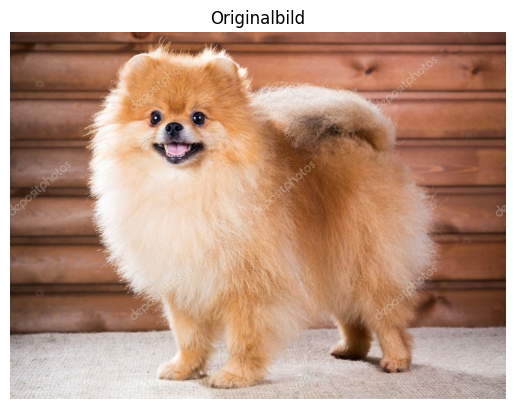

In [3]:
# Modell & Baseline-Vorhersage
model = mobilenet_v2.MobileNetV2(weights="imagenet")

pred_orig = model.predict(image)
print("Top-5-Vorhersage:")
for _, label, prob in decode_predictions(pred_orig, top=5)[0]:
    print(f"{label:20s} {prob:.3f}")

# Originalbild anzeigen
plt.imshow(raw_img.numpy())
plt.axis(False)
plt.title("Originalbild")
plt.show()


In [4]:
# FGSM-Funktion
loss_object = tf.keras.losses.CategoricalCrossentropy()

def fgsm_attack(img, label, model, eps=0.05):
    """Erzeugt ein adversariales Beispiel mittels FGSM."""
    img = tf.identity(img)
    with tf.GradientTape() as tape:
        tape.watch(img)
        pred = model(img)
        loss = loss_object(label, pred)
    gradient = tape.gradient(loss, img)
    signed_grad = tf.sign(gradient)
    adv_img = img + eps * signed_grad
    adv_img = tf.clip_by_value(adv_img, -1.0, 1.0)

    return adv_img


In [5]:
# Visualisierungs-Funktion
def visualize_perturbation(orig_img, adv_img):
    perturb = adv_img - orig_img
    sign_map = tf.sign(perturb)[0]

    sign_vis = (sign_map + 1) / 2

    plt.figure(figsize=(5,5))
    plt.imshow(sign_vis, cmap="seismic")
    plt.axis(False)
    plt.title("Perturbation")
    plt.show()

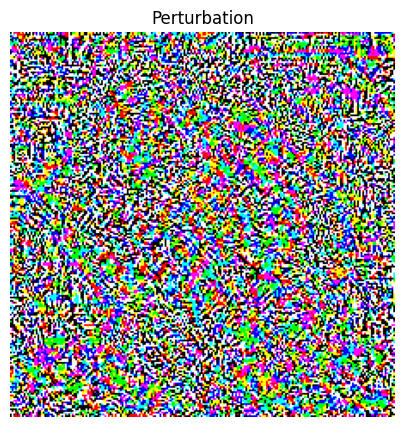

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Vorhersage nach Angriff (ε = 0.02):
chow                 0.617
Tibetan_terrier      0.007
Tibetan_mastiff      0.006
Samoyed              0.006
keeshond             0.005


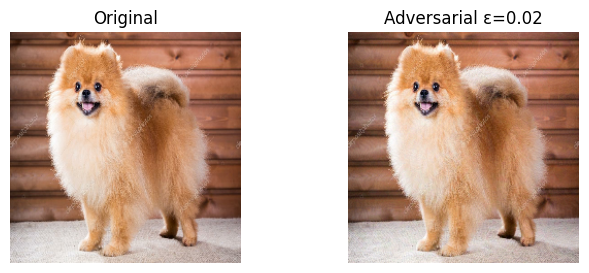

In [6]:
# Durchführung FGSM-Angriff
epsilon = 0.02

label_orig = tf.one_hot(np.argmax(pred_orig, axis=1), pred_orig.shape[-1])
adv_img = fgsm_attack(image, label_orig, model, eps=epsilon)

visualize_perturbation(image, adv_img)

pred_adv = model.predict(adv_img)
print(f"Vorhersage nach Angriff (ε = {epsilon}):")
for _, label, prob in decode_predictions(pred_adv, top=5)[0]:
    print(f"{label:20s} {prob:.3f}")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
orig_scaled = tf.image.resize(raw_img, (224, 224)).numpy().astype("uint8")
plt.imshow(orig_scaled)
plt.title("Original")
plt.axis(False)
plt.subplot(1, 2, 2)
plt.imshow(((adv_img[0] + 1) * 127.5).numpy().astype("uint8"))
plt.title(f"Adversarial ε={epsilon}")
plt.axis(False)
plt.show()


Highest-Confidence Misclassification (ε = 0.02):
chow                 0.617


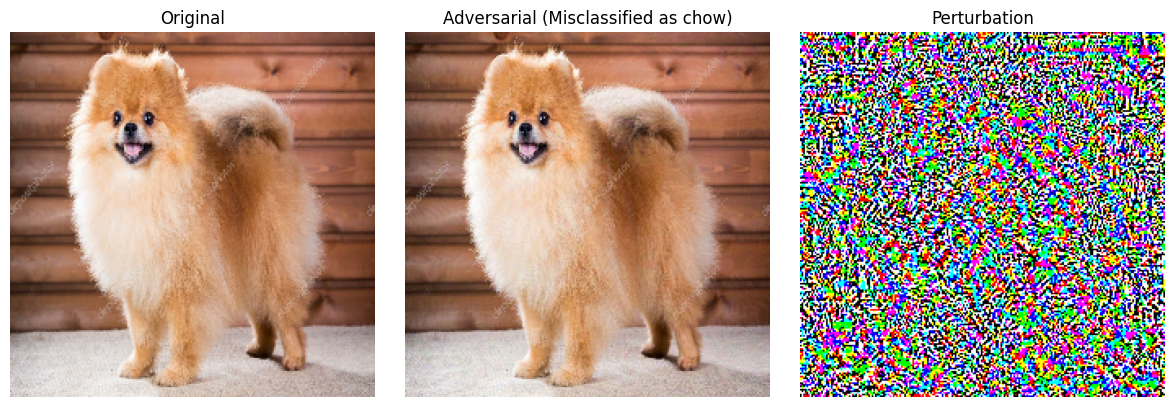

In [7]:
pred_adv_modified = pred_adv.copy()
# Set the probability of the original correct class to 0
pred_adv_modified[0, np.argmax(pred_orig)] = 0

# Find the new highest confidence class
max_conf_idx = np.argmax(pred_adv_modified)
max_conf_label = decode_predictions(pred_adv_modified, top=1)[0][0][1]
max_conf_prob = pred_adv_modified[0, max_conf_idx]

print(f"Highest-Confidence Misclassification (ε = {epsilon}):")
print(f"{max_conf_label:20s} {max_conf_prob:.3f}")

# Visualize the original, adversarial, and perturbation for context
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
orig_scaled = tf.image.resize(raw_img, (224, 224)).numpy().astype("uint8")
plt.imshow(orig_scaled)
plt.title("Original")
plt.axis(False)

plt.subplot(1, 3, 2)
plt.imshow(((adv_img[0] + 1) * 127.5).numpy().astype("uint8"))
plt.title(f"Adversarial (Misclassified as {max_conf_label})")
plt.axis(False)

plt.subplot(1, 3, 3)
perturb = adv_img - image
sign_map = tf.sign(perturb)[0]
sign_vis = (sign_map + 1) / 2
plt.imshow(sign_vis, cmap="seismic")
plt.title("Perturbation")
plt.axis(False)

plt.tight_layout()
plt.show()